In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, skew, mannwhitneyu, shapiro
import statsmodels.stats.power as smp

In [2]:
# Load the data.
df = pd.read_excel('Time_for_Bac_Fix_Comparison.xlsx')
df.head()

,Chemotaxis,Diffusion
0,19232,25479
1,11287,23572
2,21931,22680
3,19650,27111
4,26696,27574


### Descriptive Statistics

- Chemotaixs: in this case means the unaltered model with the chemotaxis equation.
- Diffusion: is the model with just the diffusion section for run and tumble, (exp(-r)).
- All units are in seconds.

In [3]:
df.describe()

,Chemotaxis,Diffusion
count,100.000000,100.00000
mean,21647.050000,25490.16000
std,4735.276292,5443.96036
min,11287.000000,6744.00000
25%,19180.750000,22842.50000
50%,21349.500000,25522.50000
75%,24439.250000,28305.00000
max,39176.000000,36457.00000


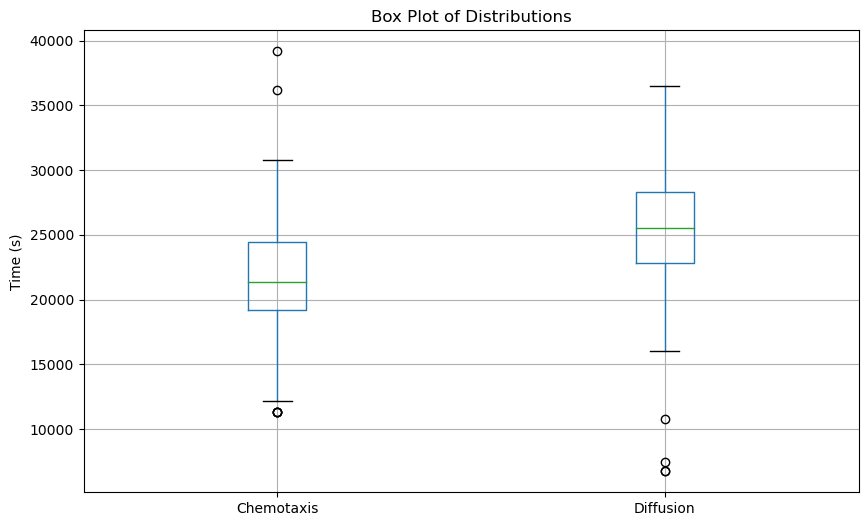

In [4]:
# Step 1: Visualize the Data
plt.figure(figsize=(10, 6))
df.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()

### Data Cleaning

In [5]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['Chemotaxis'] = remove_outliers(df, 'Chemotaxis')['Chemotaxis']
df_cleaned['Diffusion'] = remove_outliers(df, 'Diffusion')['Diffusion']
df_cleaned.describe()

,Chemotaxis,Diffusion
count,94.000000,96.000000
mean,21746.510638,26221.177083
std,3695.819212,4155.321960
min,12174.000000,16003.000000
25%,19232.000000,23099.750000
50%,21377.000000,25591.500000
75%,24377.750000,28543.750000
max,30816.000000,36457.000000


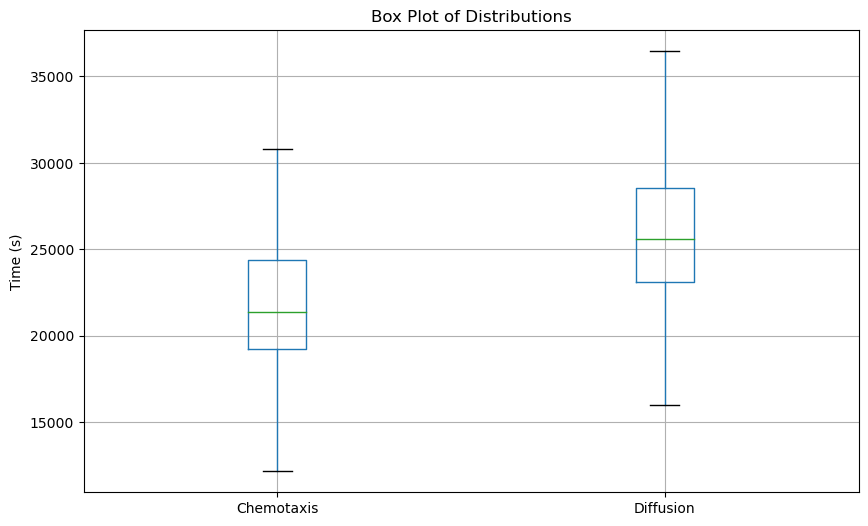

In [6]:
# Visualize the Data
plt.figure(figsize=(10, 6))
df_cleaned.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()

### Data Normalization and Histograms

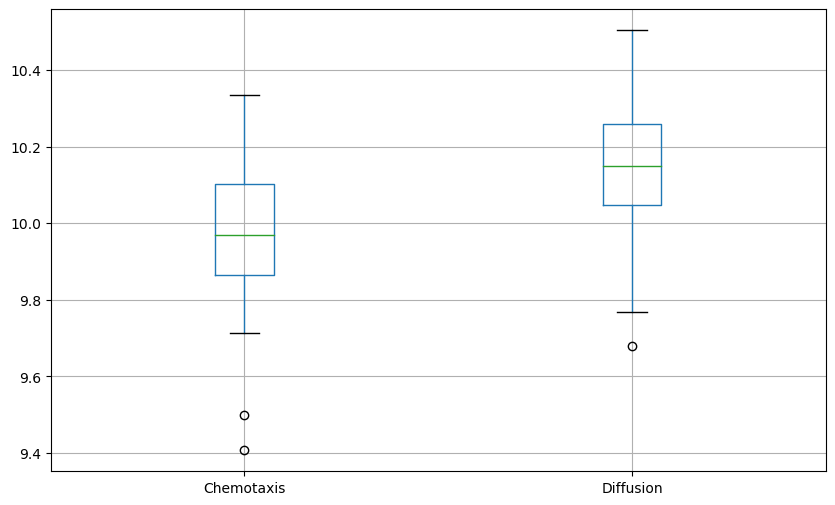

In [7]:
normalized_df_cleaned = df_cleaned.apply(lambda x: np.log(x))

# Visualize the Data
plt.figure(figsize=(10, 6))
normalized_df_cleaned.boxplot()
plt.show()

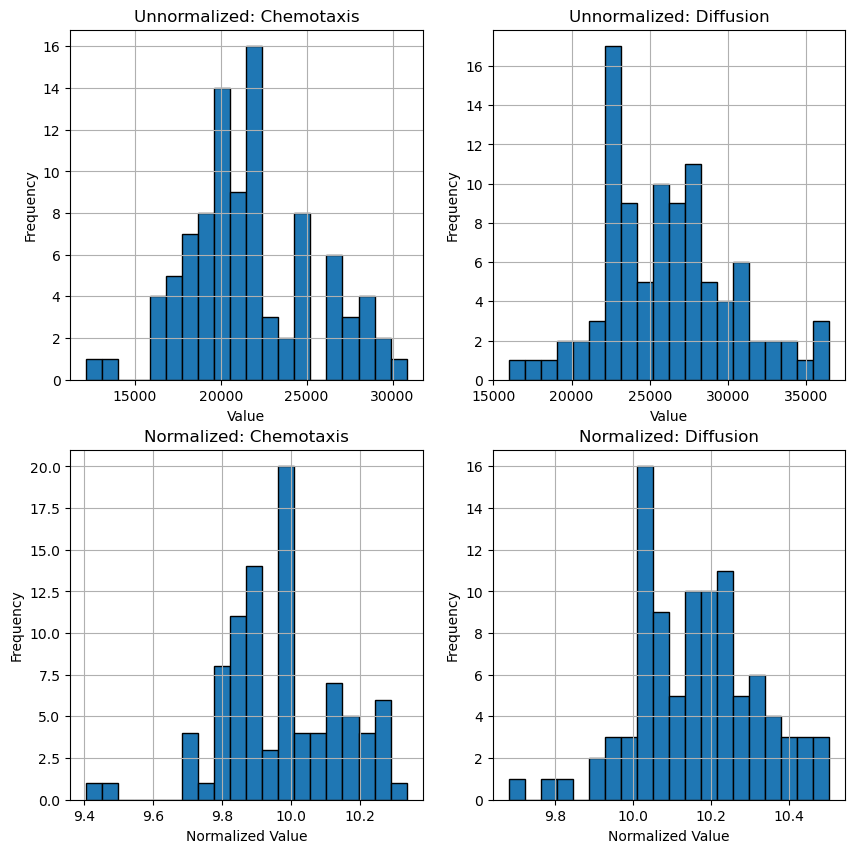

In [8]:
normalized_df_cleaned = df_cleaned.apply(lambda x: np.log(x))

# Number of columns to plot
num_columns = len(df_cleaned.columns)

# Create subplots
fig, axs = plt.subplots(2, num_columns, figsize=(5 * num_columns, 10))

# Ensure axs is 2-dimensional, even if there is only one column
if num_columns == 1:
    axs = np.array([[axs[0]], [axs[1]]])

# Plot histograms for each column in unnormalized data
for i, column in enumerate(df_cleaned.columns):
    df_cleaned[column].hist(ax=axs[0, i], bins=20, edgecolor='k')
    axs[0, i].set_title(f'Unnormalized: {column}')
    axs[0, i].set_xlabel('Value')
    axs[0, i].set_ylabel('Frequency')

# Plot histograms for each column in normalized data
for i, column in enumerate(normalized_df_cleaned.columns):
    normalized_df_cleaned[column].hist(ax=axs[1, i], bins=20, edgecolor='k')
    axs[1, i].set_title(f'Normalized: {column}')
    axs[1, i].set_xlabel('Normalized Value')
    axs[1, i].set_ylabel('Frequency')

### Power Analysis

In [9]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['Chemotaxis'] = remove_outliers(df, 'Chemotaxis')['Chemotaxis']
df_cleaned['Diffusion'] = remove_outliers(df, 'Diffusion')['Diffusion']
df_cleaned.describe()

,Chemotaxis,Diffusion
count,94.000000,96.000000
mean,21746.510638,26221.177083
std,3695.819212,4155.321960
min,12174.000000,16003.000000
25%,19232.000000,23099.750000
50%,21377.000000,25591.500000
75%,24377.750000,28543.750000
max,30816.000000,36457.000000


**Comparing Normal Equation data to others.**

Comparing the chemotaxis data, (unaltered model), with the diffusion model.

In [10]:
# Calculate Skewness of a data set.
skew_chemotaxis = skew(df['Chemotaxis'].dropna())
skew_diffusion = skew(df['Diffusion'].dropna())

# Mann-Whitney U Test
u_stat, p_value_u = mannwhitneyu(df['Chemotaxis'].dropna(), df['Diffusion'].dropna())

skew_chemotaxis, skew_diffusion, u_stat, p_value_u

(0.5762171010737761, -1.0111309627711793, 2405.0, 2.3041473088725123e-10)

Skewness:
- Both distributions are skewed, as one can tell by their score.
- Chemotaxis: 0.576
- The distribution is slightly skewed to the right.
- Diffusion: -1.011
- The distribution has a skew which goes to the left more.

Median:
- Chemotaxis: 21377.0
- Diffusion: 25591.5

Mann-Whitney U Test:
- P-value: The the extremely low p-value is less than the common significance level of 0.05.  We can safely conclude that the null hypothesis is rejected and there is significant differences between the two distributions.

Conclusion:
    There is significant differences between the two distributions, and the time for fixing with chemotaxis is more likely to be lower as the median is lower than diffusion.

**The Shapiro-Wilk test shows the data is not normally distributed so we don't need the T-Test, just the Mann-Whiteney U Test**

In [16]:
# Shapiro-Wilk Test
shapiro_chemotaxis = shapiro(df['Chemotaxis'].dropna())
shapiro_diffusion = shapiro(df['Diffusion'].dropna())

shapiro_chemotaxis, shapiro_diffusion

(ShapiroResult(statistic=0.9481931924819946, pvalue=0.0006319586536847055),
 ShapiroResult(statistic=0.9173464775085449, pvalue=1.0206168553850148e-05))

In [11]:
# T-Test
t_stat, p_value_u = ttest_ind(df['Chemotaxis'].dropna(), df['Diffusion'].dropna())

t_stat, p_value_u

(-5.3263858890992815, 2.7084511163502364e-07)

**Conclusion:**

    Even with the skew, the 75 percentile for chemotaxis is still lower than diffusion, (24377.75 vs. 28543.75).
    The 25 percentile for chemotaxis vs. diffusion: 19232.00 vs. 23099.75.

    The median of chemotaxis is lower than diffusion, (21377.0 vs. 25591.5).

    The largest factor for how quickly a mutant will fix into a population is the stochastic Poisson distribution which determines the rate of mutation, and just as importantly, the proximity of a mutation occuring.  A mutation occuring near or within the antibiotic alongside how quickly that mutant migrates towards the area to fix in a low wildtype population is the greatest variable for time.  The reason for the increased variability in both distributions of mutant fixation time is primarily due to this reason.  This variability is partially mitigated by removing outliers > 1.5*IQR.

    Even with the increased variability, chemotaxis is shown to enhance time to fixation.  The magnitude of this effect is lessened by the model being one dimensional, as random diffusion away from higher population concentrations is still directed up the antibiotic gradient.  If this model was increased to 2 dimensions, chemotaxis would play a significantly greater effection on directed migration towards food.

### Sample Size

In [18]:
# Given data
mean_chemotaxis = 21746.51
std_chemotaxis = 3695.82
n_chemotaxis = 94

mean_diffusion = 26221.18
std_diffusion = 4155.32
n_diffusion = 96

# Calculate pooled standard deviation
s_pooled = np.sqrt(((n_chemotaxis - 1) * std_chemotaxis**2 + (n_diffusion - 1) * std_diffusion**2) / (n_chemotaxis + n_diffusion - 2))

# Calculate effect size (Cohen's d)
effect_size = abs(mean_diffusion - mean_chemotaxis) / s_pooled

# Perform power analysis
alpha = 0.05
power = 0.80

analysis = smp.TTestIndPower()
required_sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')

effect_size, required_sample_size

(1.1372251074864248, 13.171014521184828)

Approximately 14 samples per group are needed to detect a statistical significance.  The sample sizes are significant.